**Example Dataset**

In [2]:
import pandas as pd

df = pd.read_csv("/content/sample_data/titanic.csv")

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n")
print(df.head())

Shape: (891, 16)

Column Names: ['Unnamed: 0', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data Types:
 Unnamed: 0       int64
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object

First 5 Rows:

   Unnamed: 0  survived  pclass     sex   age  sibsp  parch     fare embarked  \
0           0         0       3    male  22.0      1      0   7.2500        S   
1           1         1       1  female  38.0      1      0  71.2833        C   
2           2         1       3  female  26.0      0      0   7.9250        S   
3           3         1       1  female  35.0      1      0  53.1000    

**Handle Missing Values**

In [3]:
import pandas as pd

# --- Before ---
print("Missing values BEFORE imputation:")
print(df[['age', 'embark_town']].isnull().sum().to_string())

# Impute 'age' with median
age_median = df['age'].median()
cleaned_df = df.copy()
cleaned_df['age'] = cleaned_df['age'].fillna(age_median)

# Impute 'embark_town' with mode
embark_mode = cleaned_df['embark_town'].mode()[0]
cleaned_df['embark_town'] = cleaned_df['embark_town'].fillna(embark_mode)

# --- After ---
print(f"\nImputed 'age' with median: {age_median}")
print(f"Imputed 'embark_town' with mode: '{embark_mode}'")
print("\nMissing values AFTER imputation:")
print(cleaned_df[['age', 'embark_town']].isnull().sum().to_string())


Missing values BEFORE imputation:
age            177
embark_town      2

Imputed 'age' with median: 28.0
Imputed 'embark_town' with mode: 'Southampton'

Missing values AFTER imputation:
age            0
embark_town    0


Suvival Rate by Class and Gender

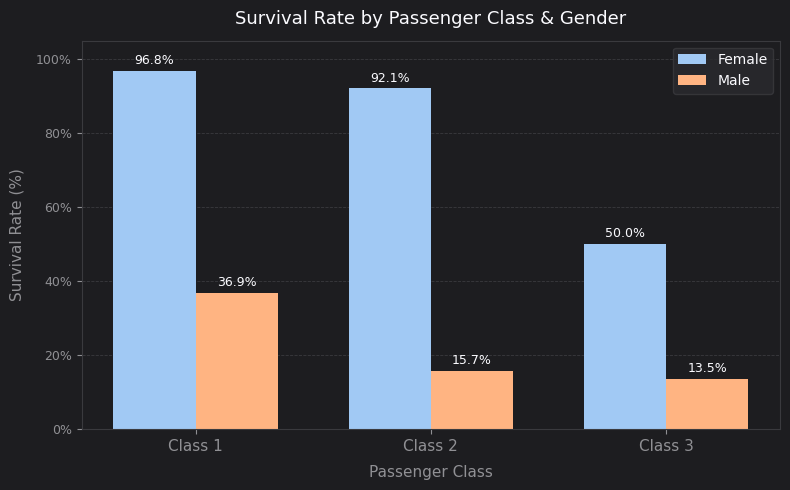

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Compute survival rate (%) by pclass and sex
survival_rates = (
    cleaned_df.groupby(['pclass', 'sex'])['survived']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'survived': 'survival_rate'})
)

# Pivot for grouped bar layout
pivot = survival_rates.pivot(index='pclass', columns='sex', values='survival_rate')

# --- Chart setup ---
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#1D1D20')
ax.set_facecolor('#1D1D20')

classes = pivot.index.tolist()
x = np.arange(len(classes))
bar_width = 0.35

female_color = '#A1C9F4'   # light blue
male_color   = '#FFB482'   # orange

bars_f = ax.bar(x - bar_width / 2, pivot['female'], width=bar_width,
                color=female_color, label='Female')
bars_m = ax.bar(x + bar_width / 2, pivot['male'],   width=bar_width,
                color=male_color,   label='Male')

# Value labels on bars
for bar in list(bars_f) + list(bars_m):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.0,
        f'{height:.1f}%',
        ha='center', va='bottom',
        color='#fbfbff', fontsize=9
    )

# Axes styling
ax.set_xticks(x)
ax.set_xticklabels([f'Class {c}' for c in classes], color='#fbfbff', fontsize=11)
ax.set_yticks(range(0, 101, 20))
ax.set_yticklabels([f'{v}%' for v in range(0, 101, 20)], color='#909094', fontsize=9)
ax.set_ylim(0, 105)
ax.set_xlabel('Passenger Class', color='#909094', fontsize=11, labelpad=8)
ax.set_ylabel('Survival Rate (%)', color='#909094', fontsize=11, labelpad=8)
ax.set_title('Survival Rate by Passenger Class & Gender', color='#fbfbff', fontsize=13, pad=12)

ax.tick_params(axis='both', colors='#909094')
for spine in ax.spines.values():
    spine.set_edgecolor('#3a3a3e')

ax.yaxis.grid(True, color='#3a3a3e', linestyle='--', linewidth=0.6)
ax.set_axisbelow(True)

legend = ax.legend(frameon=True, facecolor='#2a2a2e', edgecolor='#3a3a3e',
                   labelcolor='#fbfbff', fontsize=10)

plt.tight_layout()
survival_chart = fig
plt.show()


## 🔍 Key Insights from the Analysis

1. **The Gender Gap is Paramount:** Across all passenger classes, females survived at dramatically higher rates than males, reflecting the historical *"women and children first"* protocol.

2. **Class Gradient Impact:** Socioeconomic status played a massive role, particularly for female passengers. First-class women had a near-certain survival rate of **96.8%**, which dropped steeply to **50.0%** for those in third class.

3. **Male Survival Rates:** Survival rates for male passengers remained low across the board, peaking at only **36.9%** in first class and dropping to **13.5%** in third class.

**Survival Rate HeatMap**

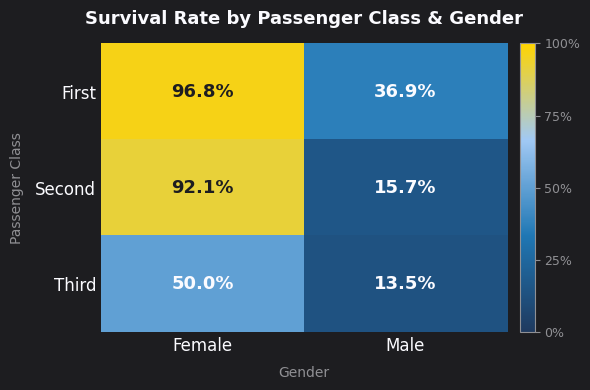

In [12]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Build pivot: rows = class, cols = sex
pivot = (
    cleaned_df.groupby(["class", "sex"])["survived"]
    .mean()
    .mul(100)
    .unstack("sex")
    .reindex(["First", "Second", "Third"])
)

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("#1D1D20")
ax.set_facecolor("#1D1D20")

# Custom colormap: dark-blue → teal → gold
cmap = mcolors.LinearSegmentedColormap.from_list(
    "survival", ["#1F3A5F", "#1F77B4", "#A1C9F4", "#ffd400"], N=256
)

im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, vmin=0, vmax=100)

# ── Axes labels ─────────────────────────────────────────────────────────────
ax.set_xticks([0, 1])
ax.set_xticklabels(pivot.columns.str.capitalize(), color="#fbfbff", fontsize=12)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(pivot.index, color="#fbfbff", fontsize=12)
ax.tick_params(length=0)

# ── Annotate each cell ───────────────────────────────────────────────────────
for row in range(pivot.shape[0]):
    for col in range(pivot.shape[1]):
        val = pivot.values[row, col]
        text_color = "#1D1D20" if val > 55 else "#fbfbff"
        ax.text(col, row, f"{val:.1f}%", ha="center", va="center",
                color=text_color, fontsize=13, fontweight="bold")

# ── Colorbar ─────────────────────────────────────────────────────────────────
cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03)
cbar.ax.yaxis.set_tick_params(color="#909094")
cbar.outline.set_edgecolor("#909094")
_cbar_ticks = [0, 25, 50, 75, 100]
cbar.set_ticks(_cbar_ticks)
cbar.set_ticklabels([f"{t}%" for t in _cbar_ticks])
cbar.ax.tick_params(labelcolor="#909094", labelsize=9)

# ── Titles & spines ──────────────────────────────────────────────────────────
ax.set_title("Survival Rate by Passenger Class & Gender", color="#fbfbff",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Gender", color="#909094", fontsize=10, labelpad=8)
ax.set_ylabel("Passenger Class", color="#909094", fontsize=10, labelpad=8)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
survival_heatmap = fig
plt.show()


# 🔥 Key Insight: Gender Was the Strongest Predictor of Survival

The heatmap reveals a **stark survival divide** driven by two factors: **gender** and **passenger class**.

## Women Survived at Dramatically Higher Rates

| Class | Female Survival | Male Survival | Gap |
|-------|----------------|---------------|-----|
| First | 96.8% | 36.9% | **+59.9 pts** |
| Second | 92.1% | 15.7% | **+76.4 pts** |
| Third | 50.0% | 13.5% | **+36.5 pts** |

## The "Women and Children First" Protocol Was Real

The evacuation protocol strongly favored women — **regardless of class**. Even a woman in Third Class (50%) had nearly **4× the survival odds** of a First Class man (36.9%).

## Class Mattered More for Women Than Men

- **First-class women** had an almost certain chance of survival at **96.8%**
- **Third-class women** saw survival drop to **50%** — still far above any male group
- Male survival rates were **uniformly low** across all classes (13–37%), suggesting class offered men little additional protection

## Bottom Line

> **Gender was the dominant survival factor.** Being female was more protective than being in First Class. For men, class provided only marginal benefit — their odds remained grim across the board.